In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

from utilities import *

In [2]:
def initializer(dimensions):

    paramettres = {}
    C = len(dimensions)

    for c in range(1, C):
        paramettres['W'+str(c)] = np.random.randn(dimensions[c], dimensions[c-1])
        paramettres['b'+str(c)] = np.random.randn(dimensions[c], 1)

    return paramettres

# paramettres = initializer([2, 32, 32, 1])
# for key, val in paramettres.items():
#     print(key, val.shape)

In [3]:
def forward_propagation(X, paramettres):
    activations = {'A0' : X}
    C = len(paramettres)//2

    for c in range(1, C+1):
        Z = paramettres['W' + str(c)].dot(activations['A' + str(c - 1)]) + paramettres['b' + str(c)]
        activations['A' + str(c)] = 1 / (1 + np.exp(1 - Z))
    
    return activations

# activations = forward_propagation(X, paramettres)
# for key, val in activations.items():
#     print(key, val.shape)

In [4]:
# def log_loss(A, y):
#     return 1/len(y)*np.sum(-y*np.log(A) - (1-y)*np.log(1-A))

In [5]:
def back_propagation(y, activations, paramettres):
    m = y.shape[1]
    C = len(paramettres)//2

    dZ = activations['A' + str(C)] - y
    gradiants = {}

    for c in reversed(range(1, C+1)):
        gradiants['dW' + str(c)] = 1 / m * np.dot(dZ, activations['A' + str(c - 1)].T)
        gradiants['db' + str(c)] =  1 / m * np.sum(dZ, axis=1, keepdims=True)
        if c > 1:
            dZ = np.dot(paramettres['W' + str(c)].T, dZ) * activations['A' + str(c - 1)] * (1 - activations['A' + str(c - 1)])
    
    return gradiants

# gradiants = back_propagation(X, y, activations, paramettres)
# for key, val in gradiants.items():
#     print(key, val.shape)

In [6]:
def update(gradiants, paramettres, learning_rate):
    C = len(paramettres)//2

    for c in range(1, C+1):
        paramettres['W' + str(c)] = paramettres['W' + str(c)] - learning_rate * gradiants['dW' + str(c)]
        paramettres['b' + str(c)] = paramettres['b' + str(c)] - learning_rate * gradiants['db' + str(c)]
    
    return paramettres

In [7]:
def predict(X, paramettres):
    activations = forward_propagation(X, paramettres)
    C = len(paramettres)//2
    return activations[f'A{C}'] >= 0.5

In [8]:
from sklearn.metrics import log_loss, accuracy_score
from tqdm import tqdm

In [9]:
from sklearn.decomposition import PCA

def visualisation(X, y, params, ax):
    """
    Trace la frontière de décision finale.
    S'adapte automatiquement aux données (2D).
    """
    if X.shape[0] != 2:
        # ---------- ACP ----------
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X.T)  # attention: sklearn attend (m, n_features)

        # Scatter des données projetées
        ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y.ravel(), cmap="summer")
        ax.set_title("Projection sur les 2 premières composantes")

        # Variance expliquée
        explained = pca.explained_variance_ratio_
        ax.bar(["PC1", "PC2"], explained)
        ax.set_title("Variance expliquée")
        return

    # Déterminer une marge relative (10% de l'étendue)
    x_min, x_max = X[0, :].min(), X[0, :].max()
    y_min, y_max = X[1, :].min(), X[1, :].max()
    x_margin = 0.1 * (x_max - x_min) if x_max != x_min else 0.5
    y_margin = 0.1 * (y_max - y_min) if y_max != y_min else 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min - x_margin, x_max + x_margin, 200),
        np.linspace(y_min - y_margin, y_max + y_margin, 200)
    )
    grid = np.c_[xx.ravel(), yy.ravel()].T
    activations = forward_propagation(grid, params)
    C = len(params) // 2
    Z = activations[f'A{C}'].reshape(xx.shape)

    # Contour de la probabilité 0.5 (frontière)
    ax.contourf(xx, yy, Z, levels=20, alpha=0.3, cmap="summer")
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=1.5)
    ax.scatter(X[0, :], X[1, :], c=y.flatten(), cmap="summer",
               edgecolors='k', s=30, linewidth=0.5)

    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_aspect('equal')
    ax.set_title('Frontière de décision finale', fontsize=12)
    ax.set_xlabel('Caractéristique 1')
    ax.set_ylabel('Caractéristique 2')

In [10]:
def neural_network(X_train, y_train, hidden_layers=(32, 32, 32),
                   X_test=None, y_test=None,
                   learning_rate=0.1, n_iter=100):
    
    dimensions = list(hidden_layers)
    dimensions.insert(0, X_train.shape[0])
    dimensions.append(y_train.shape[0])
    params = initializer(dimensions)

    train_loss, train_acc = [], []
    test_loss, test_acc = [], []

    for i in tqdm(range(n_iter)):
        activations = forward_propagation(X_train, params)
        grads = back_propagation(y_train, activations, params)
        params = update(grads, params, learning_rate)

        if i % 10 == 0:
            C = len(params) // 2
            # --- Train ---
            train_loss.append(log_loss(y_train.flatten(),
                                       activations[f'A{C}'].flatten()))
            y_pred = predict(X_train, params)
            train_acc.append(accuracy_score(y_train.flatten(), y_pred.flatten()))

            # --- Test ---
            if X_test is not None and y_test is not None:
                test_activations = forward_propagation(X_test, params)
                y_test_prob = test_activations[f'A{C}'].flatten()
                test_loss.append(log_loss(y_test.flatten(), y_test_prob))
                y_test_pred = (y_test_prob >= 0.5)
                test_acc.append(accuracy_score(y_test.flatten(), y_test_pred))

    # ---------- VISUALISATION FINALE ----------
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
    # --- Loss ---
    ax[0].plot(train_loss, label='Train loss')
    if test_loss:
        ax[0].plot(test_loss, label='Test loss')
    ax[0].set_title("Loss")
    ax[0].legend()
    
    # --- Accuracy ---
    ax[1].plot(train_acc, label='Train acc')
    if test_acc:
        ax[1].plot(test_acc, label='Test acc')
    ax[1].set_title("Accuracy")
    ax[1].legend()
    
    # --- Decision boundary ---
    visualisation(X_train, y_train, params, ax=ax[2])
    
    plt.tight_layout()
    plt.show()

Dimension de X:  (2, 100)
Dimension de y:  (1, 100)


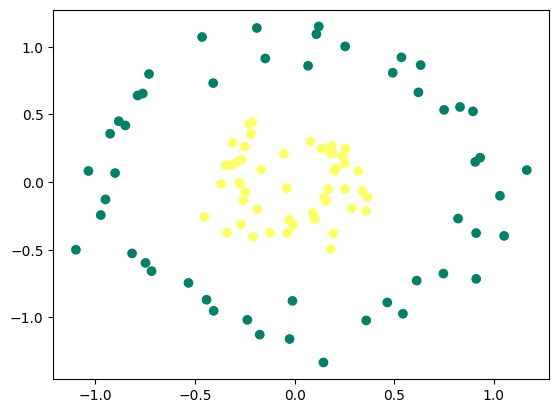

100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 3443.71it/s]


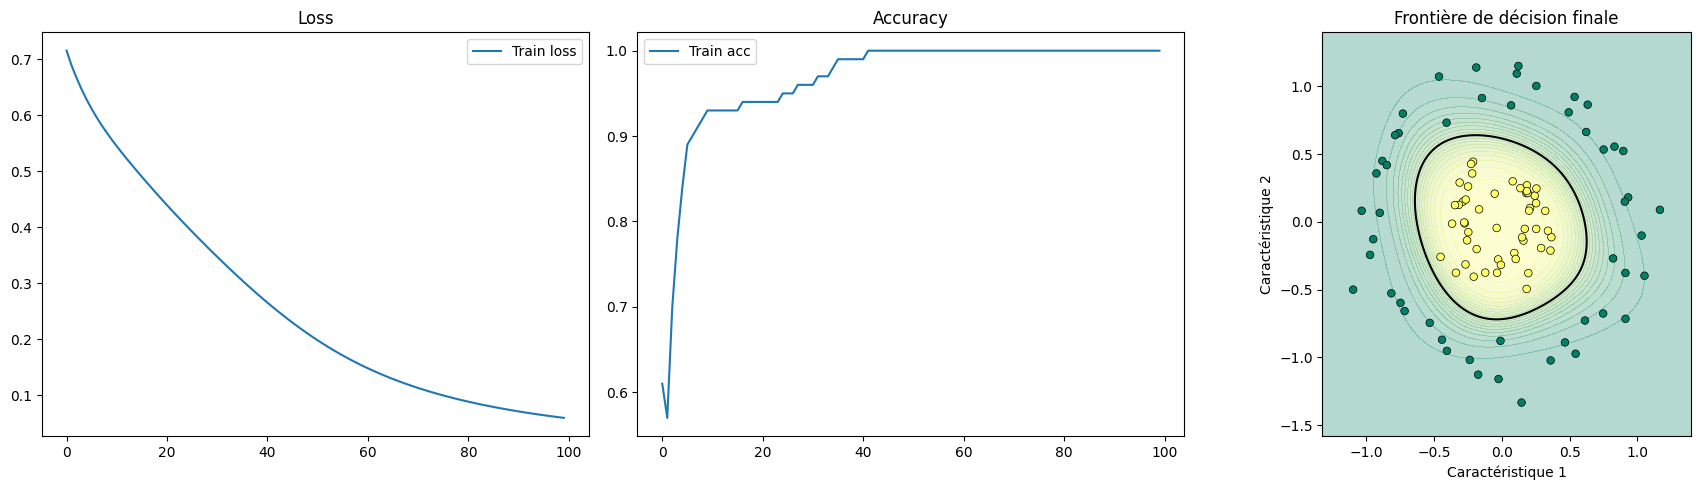

In [11]:
X, y = make_circles(n_samples=100, noise=0.1, factor=0.3, random_state=0)
X = X.T
y = y.reshape((1, y.shape[0]))

print("Dimension de X: ", X.shape)
print("Dimension de y: ", y.shape)

plt.scatter(X[0, :], X[1,:], c=y, cmap="summer")
plt.show()
p1 = neural_network(X, y, learning_rate=0.1, n_iter=1000)

In [12]:
X_train, y_train, X_test, y_test = load_data()
X_train = X_train.T
X_test = X_test.T
y_train = y_train.T
y_test = y_test.T

# Mise a l'echelle
X_train = X_train.reshape(-1, X_train.shape[-1]) / 255
X_test  = X_test.reshape(-1, X_test.shape[-1]) / 255

m_train = 300
m_test = 80
X_train = X_train[:, :m_train]
y_train = y_train[:, :m_train]
X_test = X_test[:, :m_test]
y_test = y_test[:, :m_test]

100%|██████████████████████████████████████| 1000/1000 [00:03<00:00, 269.80it/s]


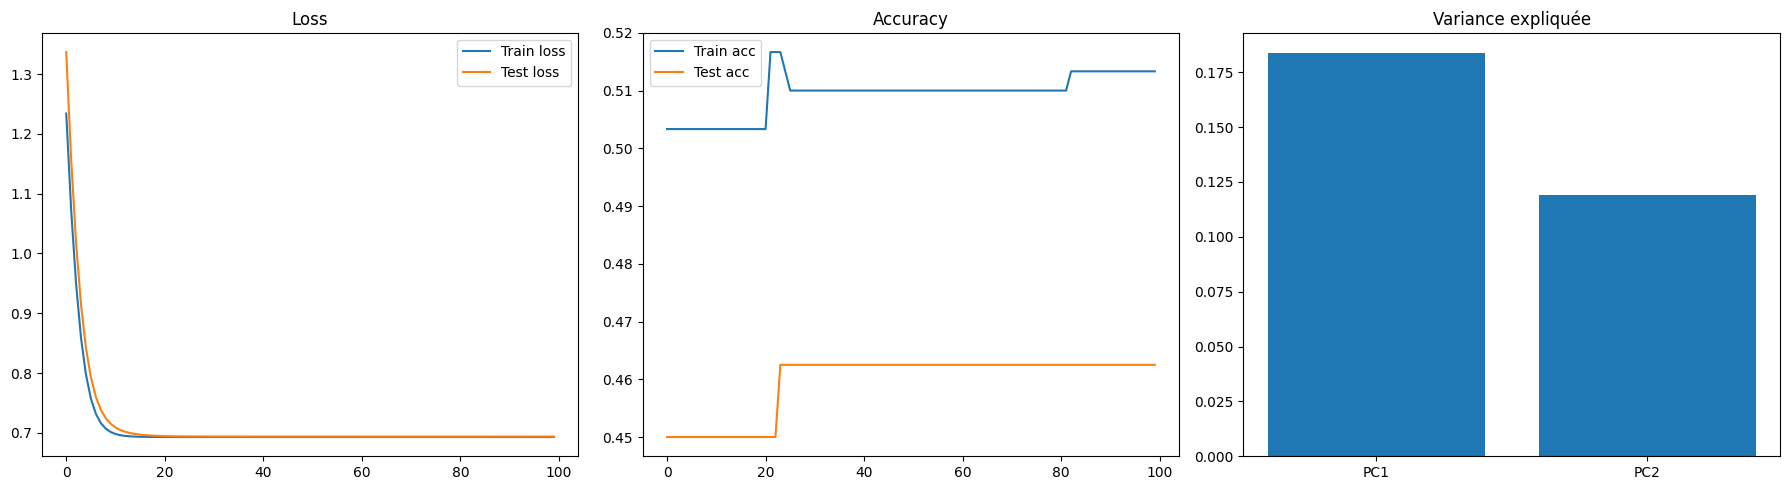

In [13]:
p2 = neural_network(X_train, y_train, hidden_layers=(2, 1), X_test=X_test, y_test=y_test, learning_rate=0.1, n_iter=1000)